# 4.3 분위수와 상자 그림

**분위수(Quantile)**
- 데이터 집합을  고정된 크기(값들의 개수)의 여러 그룹('분위')으로 나누는 값
- 중앙값은 데이터의 집합을 같은 크기의 두 그룹으로 나누기 때문에 **이분위수(2-quantile)**이다
- 중앙값은 **50 백분위수(50th percentile)**라고도 부르며, 이는 중앙값이 데이터 집합에 있는 값들의 50%보다 크다는 의미이다
- 흔히, 데이터 집합을 **사분위(quantile)**라는 네 그룹으로 나눔

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
d = np.load("exams.npy")
p = d[:,0].astype("uint32")
q = np.quantile(p, [0.0, 0.25, 0.5, 0.75, 1.0])

print()
print("Quartiles: ", q)
print()
print("Counts by quartile:")
print("    %d" % ((q[0] <= p) & (p < q[1])).sum())
print("    %d" % ((q[1] <= p) & (p < q[2])).sum())
print("    %d" % ((q[2] <= p) & (p < q[3])).sum())
print("    %d" % ((q[3] <= p) & (p <= q[4])).sum())
print()


Quartiles:  [ 18.    56.75  68.    78.   100.  ]

Counts by quartile:
    250
    237
    253
    260



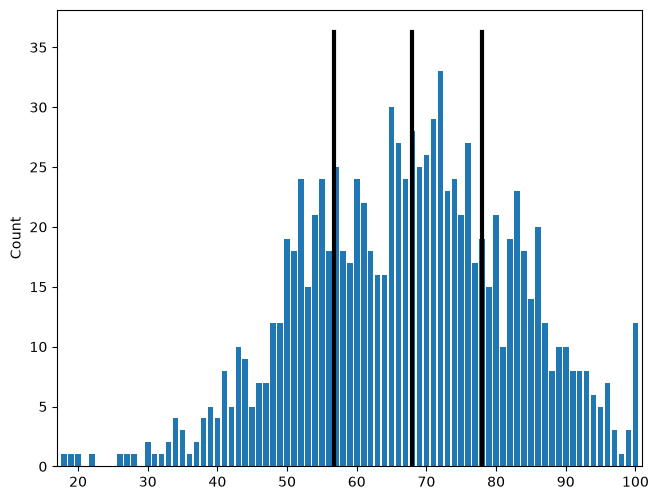

In [3]:
# 사분위수 그래프 시각화
h = np.bincount(p, minlength=100)
x = np.arange(101)
plt.bar(x,h, width=0.8*(x[1]-x[0]))
n = 1.1*h.max()
plt.plot([q[1],q[1]],[0,n], linewidth=3, color='k')
plt.plot([q[2],q[2]],[0,n], linewidth=3, color='k')
plt.plot([q[3],q[3]],[0,n], linewidth=3, color='k')
plt.xlim((p.min()-1,p.max()+1))
plt.ylabel("Count")
plt.tight_layout(pad=0,w_pad=0,h_pad=0)
# plt.savefig("quantiles_plot.png", dpi=300)
plt.show()

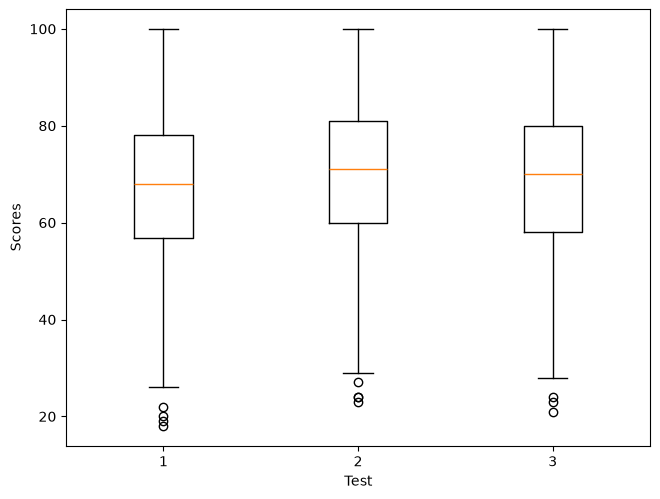

In [4]:
# box plot
plt.boxplot(d)
plt.xlabel("Test")
plt.ylabel("Scores")
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
# plt.savefig("box_plot.png", dpi=300)
plt.show()